In [1]:
import pandas as pd
from matplotlib import pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
vendas = pd.read_csv('../../datasets/vendas_2023_2024.csv')

vendas.sample(10)

,id,id_client,id_product,qtd,total,sale_date
8398,8488,5,35,15,165083.00,2023-05-17
7512,7598,5,76,2,281576.20,2024-09-17
2209,2233,48,19,14,218550.35,04-09-2024
9889,9994,43,39,10,296328.00,20-02-2023
8236,8325,5,44,15,153997.85,24-09-2024
6776,6853,48,62,8,776887.20,21-01-2024
5490,5548,40,41,1,10070.00,12-06-2023
2574,2602,35,115,8,6312.75,02-01-2023
966,979,9,58,7,723683.40,10-11-2024
9873,9978,2,33,5,33579.00,2023-08-30


In [3]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 464.0+ KB


In [4]:
print(vendas.duplicated().sum())

0


In [5]:
print(vendas.duplicated(subset='id').sum())

0


In [6]:
print(vendas.duplicated(subset=['id_client', 'id_product', 'qtd', 'sale_date'], keep=False).sum())

0


In [7]:
vendas['formated_sale_date'] = pd.to_datetime(vendas['sale_date'], format='mixed', dayfirst=True)

vendas.sample(20)

,id,id_client,id_product,qtd,total,sale_date,formated_sale_date
2848,2879,5,115,8,6312.75,2024-09-17,2024-09-17
6971,7051,38,77,15,670570.00,2024-11-30,2024-11-30
4498,4542,33,6,8,94562.00,11-11-2024,2024-11-11
158,162,12,147,15,43178.45,25-06-2024,2024-06-25
1240,1256,21,136,2,3749.65,2023-11-24,2023-11-24
8954,9050,4,29,7,255572.00,2024-03-20,2024-03-20
2710,2741,44,22,3,118359.00,2023-04-24,2023-04-24
9044,9140,5,63,9,1196638.05,02-12-2023,2023-12-02
2263,2287,34,100,15,1569004.00,12-10-2023,2023-10-12
3529,3563,7,29,1,36510.00,26-08-2024,2024-08-26


In [8]:
print(f"Data mais antiga: {vendas['formated_sale_date'].min().strftime('%Y-%m-%d')}")

print(f"Data mais recente: {vendas['formated_sale_date'].max().strftime('%Y-%m-%d')}")

Data mais antiga: 2023-01-01
Data mais recente: 2024-12-31


In [9]:
print(f"Valor total máximo: {vendas['total'].max():,.2f}")

print(f"Valor total mínimo: {vendas['total'].min():,.2f}")

print(f"Valor total médio: {vendas['total'].mean():,.2f}")

print(f"Desvio padrão do valor total: {vendas['total'].std():,.2f}")

Valor total máximo: 2,222,973.00
Valor total mínimo: 294.50
Valor total médio: 263,797.83
Desvio padrão do valor total: 390,007.18


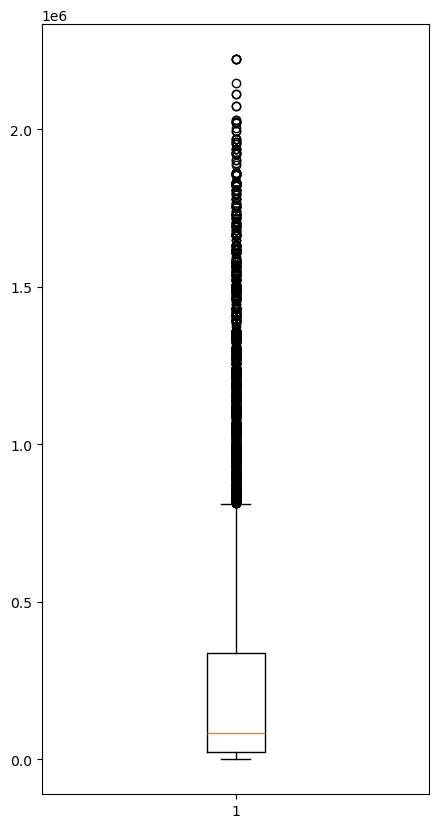

In [10]:
plt.figure(figsize=(5,10))

plt.boxplot(vendas['total'])

plt.show()

In [11]:
vendas.drop(
    columns='sale_date',
    inplace=True
)

vendas.rename(
    columns={
        'id_client': 'client_id',
        'id_product': 'product_id',
        'formated_sale_date': 'sale_date'
    },
    inplace=True
)

In [13]:
vendas.to_csv('../../datasets/vendas.csv', index=False, encoding='utf-8')